### 1) NumPy arrays & shapes 
**Goal:** Create arrays, do vectorized math, understand shapes and `.reshape`.

In [1]:
import numpy as np
v = np.arange(6)           # shape (6,)
col = v.reshape(-1, 1)     # (6,1)
row = v.reshape(1, -1)     # (1,6)
matrix = v.reshape(2, 3)  # (2,3)
print(col, type(col))
print((v.shape, col.shape, row.shape))
print((v*10).mean(), col.mean(axis=0), col.mean(axis=1))
print(matrix.mean(axis=1), matrix.mean(axis=0))
# 


[[0]
 [1]
 [2]
 [3]
 [4]
 [5]] <class 'numpy.ndarray'>
((6,), (6, 1), (1, 6))
25.0 [2.5] [0. 1. 2. 3. 4. 5.]
[1. 4.] [1.5 2.5 3.5]


In [2]:
A = np.array([[10, 11, 12],
              [20, 21, 22],
              [30, 31, 32]])

print(A[:, 1])      # -> array([11, 21, 31])  (second column)
print(A[0, :])      # -> array([10, 11, 12])  (first row)
print(A[:, 0:2])    # -> all rows, columns 0 and 1 (a 2-D slice)
print(A[:, [0,2]])  # -> all rows, columns 0 and 2 (fancy indexing)

[11 21 31]
[10 11 12]
[[10 11]
 [20 21]
 [30 31]]
[[10 12]
 [20 22]
 [30 32]]


**Exercises:**
1. Build a 3×4 matrix with `np.arange` and compute column means (`axis=0`).
2. Given `w = np.arange(8)`, show shapes `(8,)`, `(8,1)`, `(1,8)` with `reshape`.
1. Create `np.linspace(0, 1, 5)`. See what is the result. Compute square for all the numbers in this vector. (not using a loop, but directly for the whole vector)

In [ ]:
matrix = 

### 2) pandas DataFrames & dtypes
**Goal:** Build a DataFrame, inspect with `info/describe`, select/filter, add columns

In [3]:
import pandas as pd
df = pd.DataFrame({
    "city": ["Zurich","Geneva","Basel","Bern","Lausanne"],
    "pop_k": [434,203,178,144,140],
    "avg_income_k": [110.0,99.0,85.0,75.0,78.0],
    "has_lake": [True,True,False,False,True],
})
df.info()


df.describe()

df["city"] = df["city"].astype("category")
# to check the information about the function, you can run 
#df.loc?
high_income = df.loc[df["avg_income_k"] >= 85, ["city","avg_income_k","has_lake"]]
df.dtypes, high_income

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   city          5 non-null      object 
 1   pop_k         5 non-null      int64  
 2   avg_income_k  5 non-null      float64
 3   has_lake      5 non-null      bool   
dtypes: bool(1), float64(1), int64(1), object(1)
memory usage: 257.0+ bytes


(city            category
 pop_k              int64
 avg_income_k     float64
 has_lake            bool
 dtype: object,
      city  avg_income_k  has_lake
 0  Zurich         110.0      True
 1  Geneva          99.0      True
 2   Basel          85.0     False)

**Exercises:**
1. Create a DataFrame with columns `rooms`, `size_m2`, `year_built`, `price_k` (5 rows of made-up data). Show `info()` and `describe()`.
2. Add a column `price_per_m2` and filter rows where it exceeds the mean.




In [7]:
import pandas as pd

data = pd.DataFrame({
    "rooms": [2, 3, 4, 5],
    "size_m2": [45, 65, 100, 120],
    "year_built": [1990, 2005, 2010, 2020],
    "price_k": [300, 450, 700, 900] 
})

data.info()

data.describe()

print(data)

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   rooms       4 non-null      int64
 1   size_m2     4 non-null      int64
 2   year_built  4 non-null      int64
 3   price_k     4 non-null      int64
dtypes: int64(4)
memory usage: 260.0 bytes
   rooms  size_m2  year_built  price_k
0      2       45        1990      300
1      3       65        2005      450
2      4      100        2010      700
3      5      120        2020      900


In [8]:
import pandas as pd

data = {
    "rooms": [2, 3, 4, 5, 3],
    "size_m2": [50, 75, 100, 130, 80],
    "year_built": [1990, 2005, 2010, 2020, 1998],
    "price_k": [250, 360, 500, 780, 400]
}

df = pd.DataFrame(data)

print(df)

   rooms  size_m2  year_built  price_k
0      2       50        1990      250
1      3       75        2005      360
2      4      100        2010      500
3      5      130        2020      780
4      3       80        1998      400


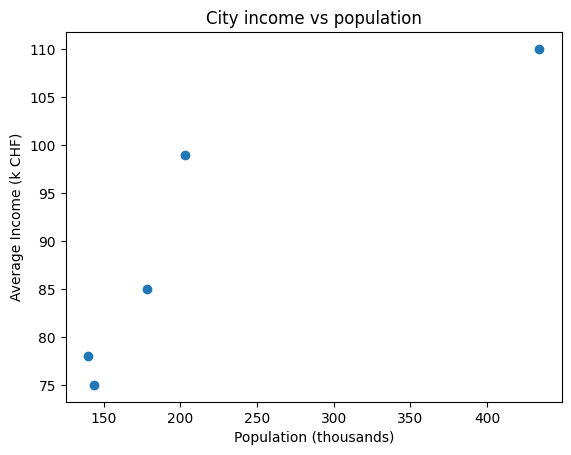

In [4]:
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(df["pop_k"], df["avg_income_k"])  # single plot, default colors
plt.xlabel("Population (thousands)")
plt.ylabel("Average Income (k CHF)")
plt.title("City income vs population")
plt.show()

In [10]:
from sklearn.linear_model import LinearRegression
import numpy as np
X1d = np.linspace(0, 10, 6)     # shape (6,)
print(X1d)
y = 2*X1d + 1
# To see what happens when wrong shape: the code below would fail:
#LinearRegression().fit(X1d, y)
# also - the data is not realistic here, just for demo

# Fix:
X = X1d.reshape(-1, 1)          # (6,1)
lin = LinearRegression().fit(X, y)
print(lin.coef_, lin.intercept_ )  # should be close to 2 and 1
print(lin.score(X, y))             # should be 1.0, perfect fit

[ 0.  2.  4.  6.  8. 10.]
[2.] 1.0
1.0


### 4)Simple Linear Regression
Predict salary (k$) from years of experience.


slope: 4.999999999999997
intercept: 80.00000000000001
R^2: 0.6338461538461537
Predicted salary (6 yrs): 110.0


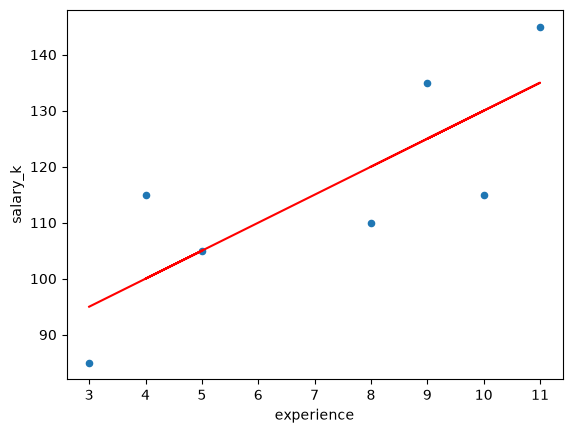

In [9]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
df = pd.DataFrame({ 'experience':[3,5,4,10,9,11,8], 'salary_k':[85,105,115,115,135,145,110] })
df.plot.scatter(x='experience', y='salary_k')
X = df[['experience']] 
y = df['salary_k']
model = LinearRegression().fit(X,y)
print('slope:', model.coef_[0])
print('intercept:', model.intercept_)
print('R^2:', model.score(X,y))
plt.plot(X, model.predict(X), color='red')

print('Predicted salary (6 yrs):', model.predict(pd.DataFrame({'experience':[6]}))[0])

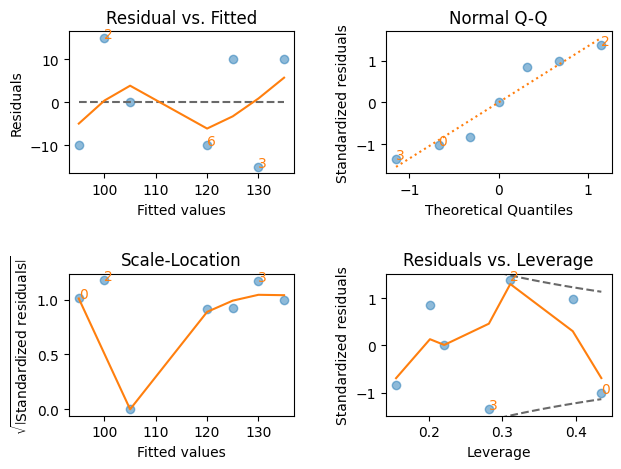

In [ ]:
#%pip install lmdiag 
import lmdiag
fig = lmdiag.plot(model, X, y)     